### Executa um fluxo de trabalho desde o pré-processamento dos dados até o treinamento e avaliação comparativa de múltiplos modelos de regressão supervisionada para prever calor de combustão
1. CARREGAMENTO E TRATAMENTO DOS DADOS
2. GERAÇÃO DE FEATURES (DESCRITORES)
3. DIVISÃO DOS DADOS TREINO/TESTE
4. DEFINIÇÃO DOS MODELOS, TREINO E PREDIÇÃO
5. AVALIAÇÃO DE MÉTRICAS E VISUALIZAÇÃO COMPARATIVA

## Open Data

In [1]:
import pandas as pd
from gaussian_tools.extract_molecule_data import Molecule, is_normal_termination

import os

path = r"C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\database\CP-QSAR-Gaussian_vacuum"

df_base = pd.read_excel(r'../database/data/data.xlsx')
df_base['filename'] = [f"{id_sample}.log" for id_sample in df_base['ID Sample']]
df_base = df_base[df_base['filename'].isin(os.listdir(path))]

df_base.columns

Index(['FORMULA', 'MM (g/mol)', 'ORIGINAL_NAME', 'Heat_of_combustion_kj/mol',
       'Dataset', 'ID Sample', 'filename'],
      dtype='object')

In [2]:
data = []
for idx, row in df_base.iterrows():
    mol_filename = os.path.join(path, row['filename'])
    mol = Molecule(mol_filename)
    if is_normal_termination(mol_filename):
        data.append({
            'ID Sample': row['ID Sample'],
            'HeatOfCombustion': row['Heat_of_combustion_kj/mol'],
            'IUPACname': row['ORIGINAL_NAME'],
            'MM': row['MM (g/mol)'],
            "FM": row['FORMULA'],
            'HOMO': mol.HOMO,
            "LUMO": mol.LUMO,
            "GAP": mol.GAP,
            "CV": mol.CV,
            "Dipole": mol.dipole,
            "Enthalpy": mol.Ent
        })
    else:
        print(f"Calculation did not terminate normally for {row['filename']}")
df = pd.DataFrame(data)


In [3]:
import numpy as np

IP = -(df.HOMO)
EA = -(df.LUMO)
df['CP'] = (IP + EA) / 2
df['EN'] = -df['CP']
df['CH'] = (IP - EA) / 2
df["CS"] = 1 / (2 * df['CH'])
df['EI'] = (df['EN']) ** 2 / (2 * df['CH'])
df['e+'] = ((3 * IP + EA) ** 2) / (16 * (IP - EA))
df['e-'] = ((IP + 3 * EA) ** 2) / (16 * (IP - EA))
df['Ne'] = df['e-'] - df['e+']
df['DETmax'] = -(df['CP'] / df['CH'])
df['DEC'] = -((df['CP'] ** 2) / (2 * df['CH']))

df

,ID Sample,HeatOfCombustion,IUPACname,MM,FM,HOMO,LUMO,GAP,CV,Dipole,...,CP,EN,CH,CS,EI,e+,e-,Ne,DETmax,DEC
0,HXAE0128,4149.00000,n-Hexane,86.110,C₆H₁₄,-0.36896,-0.02534,-0.34362,29.311,0.0000,...,0.197150,-0.197150,0.171810,2.910191,0.113114,0.233165,0.036015,-0.197150,-1.147489,-0.113114
1,HPTE0123,4756.20000,n-Heptane,100.130,C₇H₁₆,-0.36379,-0.02589,-0.33790,34.094,0.0908,...,0.194840,-0.194840,0.168950,2.959455,0.112349,0.230887,0.036047,-0.194840,-1.153241,-0.112349
2,DYLE0111,4808.10000,"2,2-Dimethylpentane",100.130,C₇H₁₆,-0.32201,-0.02826,-0.29375,24.434,1.9842,...,0.175135,-0.175135,0.146875,3.404255,0.104416,0.210343,0.035208,-0.175135,-1.192409,-0.104416
3,TPTE0164,4804.00000,"2,2,3-Trimethylbutane",100.130,C₇H₁₆,-0.36210,-0.02767,-0.33443,35.870,0.0767,...,0.194885,-0.194885,0.167215,2.990162,0.113567,0.231911,0.037026,-0.194885,-1.165476,-0.113567
4,OTAE0049,5447.90000,n-Octane,114.140,C₈H₁₈,-0.35977,-0.02629,-0.33348,38.947,0.0000,...,0.193030,-0.193030,0.166740,2.998681,0.111733,0.229090,0.036060,-0.193030,-1.157671,-0.111733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,EBBB0051,18736.37892,(3E)‐1‐(benzenesulfonyl)‐2‐(4‐bromophenyl)‐3‐[...,612.360,C28H22Br2NO3S,-0.30618,-0.08448,-0.22170,118.888,3.8984,...,0.195330,-0.195330,0.110850,4.510600,0.172097,0.283618,0.088288,-0.195330,-1.762111,-0.172097
163,DITE0001,8069.64000,"2,5-Di-tert-butylhydroquinone (DTBHQ)",222.328,C14H22O2,-0.25704,-0.03595,-0.22109,70.437,3.1993,...,0.146495,-0.146495,0.110545,4.523045,0.097068,0.184134,0.037639,-0.146495,-1.325207,-0.097068
164,TEBU0076,5465.50000,Tert-butyl hydroquinone (TBHQ),166.220,C10H14O2,-0.26357,-0.03333,-0.23024,48.556,2.6213,...,0.148450,-0.148450,0.115120,4.343294,0.095715,0.184330,0.035880,-0.148450,-1.289524,-0.095715
165,BLBE0004,5609.93000,4-Phenyl-1-butyne,130.190,C10H10,-0.30668,-0.02782,-0.27886,34.706,0.6431,...,0.167250,-0.167250,0.139430,3.586029,0.100310,0.201364,0.034114,-0.167250,-1.199527,-0.100310


## Validation Gaussian

In [4]:
from gaussian_tools.extract_molecule_data import Molecule, is_normal_termination
from gaussian_tools.molecular_coordinates_tools import read_coords
from gaussian_tools.periodic_table import get_periodic_table
import numpy as np

periodic_table_mm = {}
for element, data in get_periodic_table().items():
    mm = sum(np.array(data['isotopic_weights']) * np.array(data['abundances']))
    periodic_table_mm[element] = mm

data = []    
for idx, row in df.iterrows():
    filename = os.path.join(path, f"{row['ID Sample']}.log")
    mol = Molecule(filename)
    
    mol_data = {"ID Sample": row["ID Sample"], "filename_gaussian": filename}


    coords = read_coords(filename)
    mol_formula_dict = pd.DataFrame(coords)[0].value_counts().to_dict()

    new_mol_formula_dict = {}
    for element in ["C", "H", "O", "N", "S", "Br", "Cl" ]:
        if element in mol_formula_dict:
            new_mol_formula_dict[element] = mol_formula_dict[element]
        # else:
        #     new_mol_formula_dict[element] = 0
    mm = 0
    fm = ""
    for element, count in new_mol_formula_dict.items():
        mm += periodic_table_mm[element] * count
        if count > 1:        
            fm += f"{element}{count}"
        else:
            fm += f"{element}"
    mol_data["MM_gaussian"] = mm
    mol_data["FM_gaussian"] = fm



    # mol_data.update( new_mol_formula_dict )

    data.append(mol_data)

df = df.merge(pd.DataFrame(data), on="ID Sample")
df['mass_dif'] = df['MM'] - df['MM_gaussian']

df[['ID Sample', 'mass_dif', 'MM', 'MM_gaussian', 'FM', 'FM_gaussian']]

,ID Sample,mass_dif,MM,MM_gaussian,FM,FM_gaussian
0,HXAE0128,-0.067885,86.110,86.177885,C₆H₁₄,C6H14
1,HPTE0123,-0.074874,100.130,100.204874,C₇H₁₆,C7H16
2,DYLE0111,13.995651,100.130,86.134349,C₇H₁₆,C5H10O
3,TPTE0164,-0.074874,100.130,100.204874,C₇H₁₆,C7H16
4,OTAE0049,-0.091863,114.140,114.231863,C₈H₁₈,C8H18
...,...,...,...,...,...,...
162,EBBB0051,-76.882205,612.360,689.242205,C28H22Br2NO3S,C28H19O3NSBr3
163,DITE0001,-0.000798,222.328,222.328798,C14H22O2,C14H22O2
164,TEBU0076,-0.000843,166.220,166.220843,C10H14O2,C10H14O2
165,BLBE0004,-0.000129,130.190,130.190129,C10H10,C10H10


In [5]:
df = df[df['mass_dif'] < 0.5][['ID Sample', 'HeatOfCombustion', 'IUPACname', 'MM', 'FM', 'HOMO',
       'LUMO', 'GAP', 'CV', 'Dipole', 'Enthalpy', 'CP', 'EN', 'CH', 'CS', 'EI',
       'e+', 'e-', 'Ne', 'DETmax', 'DEC']]

#[['ID Sample', 'mass_dif', 'MM', 'MM_gaussian', 'FM', 'FM_gaussian']]

## Validation SMILES Rdkit

In [6]:
# Verificar se df foi definido nas células anteriores
if 'df' not in locals():
    print("⚠️  ERRO: 'df' não foi definido nas células anteriores!")
    print("Execute as células 2-7 primeiro antes de continuar.")
    raise NameError("df não foi definido. Certifique-se de executar as células anteriores em ordem.")

# import pubchempy as pcp

# ## obter smile apartir do nome iupac
# def get_molecule_smile(compound_name):
#     compounds = pcp.get_compounds(compound_name, 'name')    
    
#     if compounds:
#         mol = compounds[0] 
#         smile = None
#         for item in mol.__dict__['_record']['props']:
#             if item['urn']['label'] == "SMILES":
#                 if 'sval' in item['value']:
#                     smile = item['value']['sval']
#         if not smile:
#             print(f"SMILES não encontrado para '{compound_name}'.")
#         return smile
#     else:
#         print(f"Nenhum composto encontrado para '{compound_name}' em PubChem.")
#         return None



import pandas as pd
df_menor = pd.read_excel(r"../database/data/Calorific_Value_NIST_Vacuum.xlsx")
df_menor


df = df.merge(df_menor[['ID Sample', "SMILES"]], on="ID Sample")




# Usando rdkit, a partir do smiles "CCOC(C)OCC" obter a formula molecular e a massa molecular
from rdkit import Chem
from rdkit.Chem import Descriptors

fm_rdkit = []
mm_rdkit = []
for idx, row in df.iterrows():
    smiles = row["SMILES"]
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fm_rdkit.append( Chem.rdMolDescriptors.CalcMolFormula(mol) )
        mm_rdkit.append( Descriptors.MolWt(mol) )
    else:
        print("Invalid SMILES:", smiles)
        fm_rdkit.append( None )
        mm_rdkit.append( None )


df["MM_rdkit"] = mm_rdkit
df["FM_rdkit"] = fm_rdkit

df['mass_dif'] = df['MM'] - df['MM_rdkit']




df = df[df['mass_dif'] < 0.5][['ID Sample', 'HeatOfCombustion', 'IUPACname', 'MM', 'FM', 'HOMO',
       'LUMO', 'GAP', 'CV', 'Dipole', 'Enthalpy', 'CP', 'EN', 'CH', 'CS', 'EI',
       'e+', 'e-', 'Ne', 'DETmax', 'DEC', 'SMILES']]

#[['ID Sample', 'IUPACname', 'MM', 'FM', 'FM_rdkit', 'mass_dif', 'SMILES', 'LogHeatOfCombustion']]

In [7]:
df
#df.to_csv(os.path.join(os.path.dirname(r"../database/data/data.xlsx"), "data_152_moleculas.csv"), index=False, encoding="utf-8-sig")

,ID Sample,HeatOfCombustion,IUPACname,MM,FM,HOMO,LUMO,GAP,CV,Dipole,...,EN,CH,CS,EI,e+,e-,Ne,DETmax,DEC,SMILES
0,HXAE0128,4149.0000,n-Hexane,86.1100,C₆H₁₄,-0.36896,-0.02534,-0.34362,29.311,0.0000,...,-0.197150,0.171810,2.910191,0.113114,0.233165,0.036015,-0.197150,-1.147489,-0.113114,CCCCCC
1,HPTE0123,4756.2000,n-Heptane,100.1300,C₇H₁₆,-0.36379,-0.02589,-0.33790,34.094,0.0908,...,-0.194840,0.168950,2.959455,0.112349,0.230887,0.036047,-0.194840,-1.153241,-0.112349,CCCCCCC
2,TPTE0164,4804.0000,"2,2,3-Trimethylbutane",100.1300,C₇H₁₆,-0.36210,-0.02767,-0.33443,35.870,0.0767,...,-0.194885,0.167215,2.990162,0.113567,0.231911,0.037026,-0.194885,-1.165476,-0.113567,CC(C)C(C)(C)C
3,OTAE0049,5447.9000,n-Octane,114.1400,C₈H₁₈,-0.35977,-0.02629,-0.33348,38.947,0.0000,...,-0.193030,0.166740,2.998681,0.111733,0.229090,0.036060,-0.193030,-1.157671,-0.111733,CCCCCCCC
4,MLHE0136,5464.7000,2-Methylheptane,114.1400,C₈H₁₈,-0.35909,-0.02760,-0.33149,39.490,0.0853,...,-0.193345,0.165745,3.016682,0.112770,0.230161,0.036816,-0.193345,-1.166521,-0.112770,CCCCCC(C)C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,NEBP0050,11777.4368,N‐{2‐[(2E)‐3‐(4‐bromophenyl)prop‐2‐enoyl]pheny...,441.0034,C21H16BrNO3S,-0.30453,-0.08513,-0.21940,88.941,7.0105,...,-0.194830,0.109700,4.557885,0.173012,0.284139,0.089309,-0.194830,-1.776026,-0.173012,[H]N(C1=C([H])C([H])=C([H])C([H])=C1C(=O)C(\[H...
150,DITE0001,8069.6400,"2,5-Di-tert-butylhydroquinone (DTBHQ)",222.3280,C14H22O2,-0.25704,-0.03595,-0.22109,70.437,3.1993,...,-0.146495,0.110545,4.523045,0.097068,0.184134,0.037639,-0.146495,-1.325207,-0.097068,CC(C)(C)C1=CC(=C(C=C1O)C(C)(C)C)O
151,TEBU0076,5465.5000,Tert-butyl hydroquinone (TBHQ),166.2200,C10H14O2,-0.26357,-0.03333,-0.23024,48.556,2.6213,...,-0.148450,0.115120,4.343294,0.095715,0.184330,0.035880,-0.148450,-1.289524,-0.095715,CC(C)(C)c1cc(O)ccc1O
152,BLBE0004,5609.9300,4-Phenyl-1-butyne,130.1900,C10H10,-0.30668,-0.02782,-0.27886,34.706,0.6431,...,-0.167250,0.139430,3.586029,0.100310,0.201364,0.034114,-0.167250,-1.199527,-0.100310,C#CCCC1=CC=CC=C1


## HeatOfCombustion Scale

In [8]:
# ===== controle da escala do alvo (HC) =====
# antigo: o notebook treinava SEMPRE em ln(HC) usando df['LogHeatOfCombustion'] e também reportava/plotava tudo em ln(HC).
# novo: você controla a escala do alvo via 'target_scale' e centraliza a transformação/inversão em funções (reprodutível e sem duplicação).

target_scale = "log"  # "log" (treina em ln(HC)) ou "raw" (treina em HC na escala original)
use_y_scaler = False  # no notebook atual NÃO há padronização adicional em y; mantenha False

import numpy as np

def y_forward(hc):
    """HC (kJ/mol) -> escala usada no modelo."""
    hc = np.asarray(hc, dtype=float)

    # antigo: havia suporte a outras bases de log (ex.: outras bases (removidas))
    # novo: apenas duas opções: 'raw' (HC) ou 'log' (ln(HC))
    if target_scale == "raw":
        return hc
    if target_scale == "log":
        return np.log(hc)  # ln(HC)
    raise ValueError("target_scale inválido: use 'log' ou 'raw'")

def y_inverse(y_model):
    """Escala do modelo -> HC (kJ/mol), invertendo ln(HC)."""
    y_model = np.asarray(y_model, dtype=float)

    # antigo: havia inversão condicional (exp para ln, 10** para outras bases (removidas))
    # novo: apenas duas opções: 'raw' (identidade) ou 'log' (exp)
    if target_scale == "raw":
        return y_model
    if target_scale == "log":
        return np.exp(y_model)  # inversão correta do ln(HC)
    raise ValueError("target_scale inválido: use 'log' ou 'raw'")

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# antigo: df['LogHeatOfCombustion'] = np.log(df['HeatOfCombustion'])
# novo: mantém a coluna ln(HC) para diagnóstico/EDA, mas valida positividade e deixa explícito que é ln (log natural).
if (df['HeatOfCombustion'] <= 0).any():
    raise ValueError("HeatOfCombustion contém valores <= 0; log não é definido. Verifique o dataset.")

df['LogHeatOfCombustion'] = np.log(df['HeatOfCombustion'])  # ln(HC)


✅ Gráficos salvos em PNG e SVG na pasta:
C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures


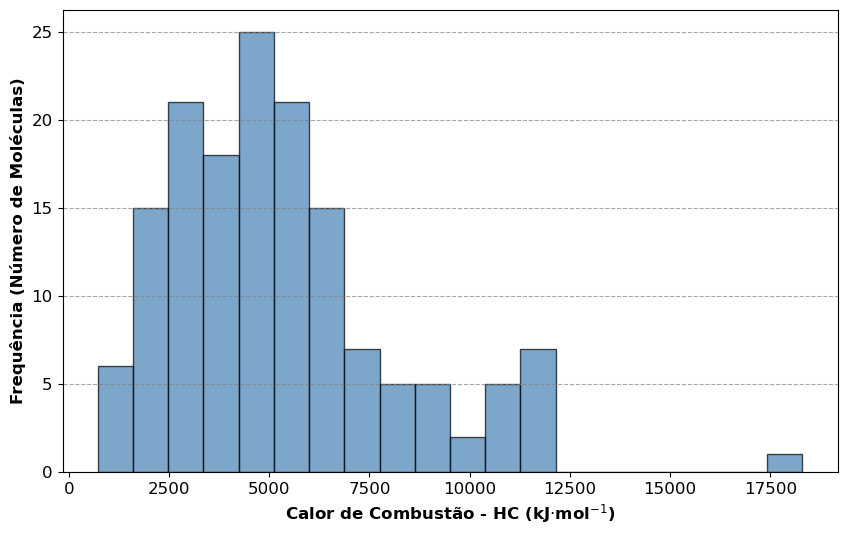

In [10]:
fig, ax = plt.subplots(1, figsize=(10, 6))
ax.hist(df['HeatOfCombustion'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_facecolor('white') # Fundo branco
ax.grid(axis='y', alpha=0.75)
ax.set_xlabel('Calor de Combustão - HC (kJ$\cdot$mol$^{-1}$)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequência (Número de Moléculas)', fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
#ax.set_title('Distribuição do Calor de Combustão Experimental', fontsize=14)

ax.tick_params(axis="x", labelsize=12)  # tamanho dos números no eixo x
ax.tick_params(axis="y", labelsize=12)  # tamanho dos números no eixo y

#  Forçar bordas pretas no grafico main 
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8) # Ajuste a grossura da borda aqui

#EXPORTAR IMAGEM EM PNG, SVG E PDF

name_arq = "histograma-HC"
caminho = r"C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures"
caminho_completo = os.path.join(caminho, name_arq)

# 1. Salvar PNG (Alta Resolução)
caminho_png = os.path.join(caminho, name_arq + ".png")
fig.savefig(caminho_png, dpi=600, bbox_inches='tight', facecolor='white')

# 2. Salvar SVG (VETORIAL - Para Inkscape/Edição)
caminho_svg = os.path.join(caminho, name_arq + ".svg")
fig.savefig(caminho_svg, format='svg', bbox_inches='tight', facecolor='white')

print(f"✅ Gráficos salvos em PNG e SVG na pasta:\n{caminho}")

plt.show()


✅ Gráficos salvos em PNG e SVG na pasta:
C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures


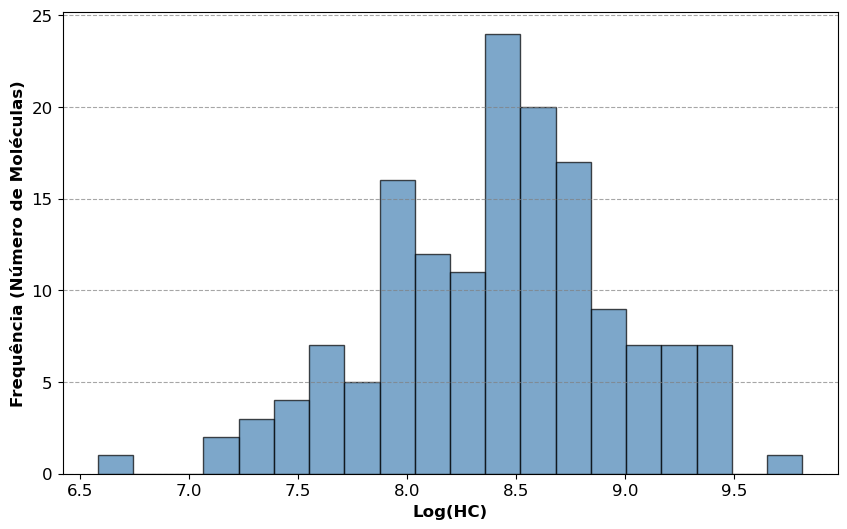

In [11]:
fig, ax = plt.subplots(1, figsize=(10, 6))
ax.hist(df['LogHeatOfCombustion'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_facecolor('white') # Fundo branco
ax.grid(axis='y', alpha=0.75)
ax.set_xlabel('Log(HC)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequência (Número de Moléculas)', fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
#ax.set_title('Distribuição do LogHC', fontsize=14)

ax.tick_params(axis="x", labelsize=12)  # tamanho dos números no eixo x
ax.tick_params(axis="y", labelsize=12)  # tamanho dos números no eixo y

#  Forçar bordas pretas no grafico main 
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8) # Ajuste a grossura da borda aqui

#EXPORTAR IMAGEM EM PNG, SVG E PDF

name_arq = "histograma-LogHC"
caminho = r"C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures"
caminho_completo = os.path.join(caminho, name_arq)

# 1. Salvar PNG (Alta Resolução)
caminho_png = os.path.join(caminho, name_arq + ".png")
fig.savefig(caminho_png, dpi=600, bbox_inches='tight', facecolor='white')

# 2. Salvar SVG (VETORIAL - Para Inkscape/Edição)
caminho_svg = os.path.join(caminho, name_arq + ".svg")
fig.savefig(caminho_svg, format='svg', bbox_inches='tight', facecolor='white')

print(f"✅ Gráficos salvos em PNG e SVG na pasta:\n{caminho}")





plt.show()

In [12]:
# antigo: df = df[df['LogHeatOfCombustion'] > 7]
# novo: o corte em ln(HC) > 7 é equivalente a HC > exp(7).
#       Isso evita depender da coluna log para filtrar e mantém a interpretação na escala original.

loghc_min = 7.0
hc_min = np.exp(loghc_min)  # como usamos ln(HC)

df = df[df['HeatOfCombustion'] > hc_min]
len(df)


152

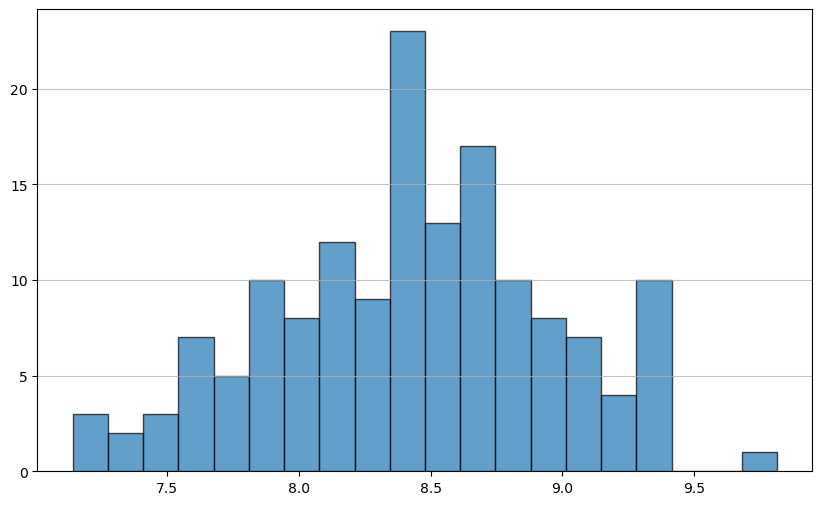

In [13]:
fig, ax = plt.subplots(1, figsize=(10, 6))
ax.hist(df['LogHeatOfCombustion'], bins=20, edgecolor='black', alpha=0.7)
ax.grid(axis='y', alpha=0.75)
plt.show()

In [14]:
# faça teste de normalidade shapiro wilk em df['LogHeatOfCombustion']
from scipy import stats
_, pvalue = stats.shapiro(df['LogHeatOfCombustion'])

pvalue


np.float64(0.38497073897180545)

In [15]:
df[["HeatOfCombustion", "LogHeatOfCombustion"]].describe()

,HeatOfCombustion,LogHeatOfCombustion
count,152.000000,152.000000
mean,5274.629277,8.431228
std,2867.742563,0.537532
min,1264.300000,7.142274
25%,3211.550000,8.074379
50%,4642.650000,8.443037
75%,6462.125000,8.773713
max,18299.271967,9.814617


## Feature Engineering

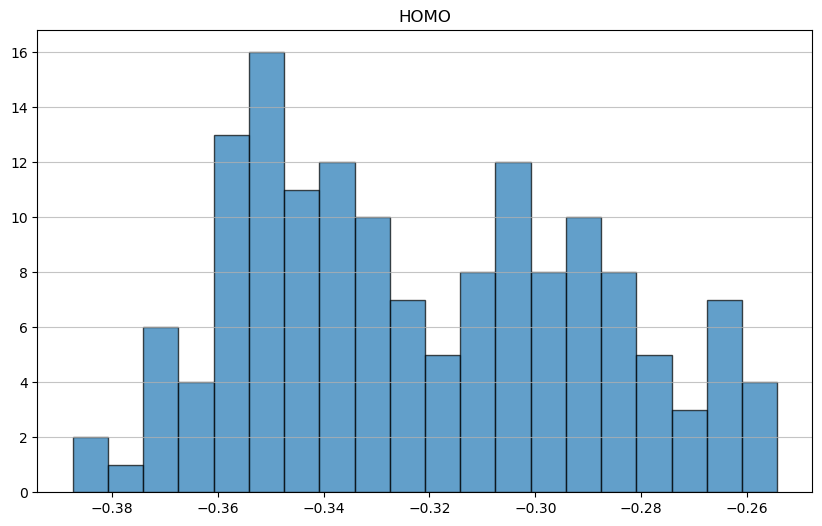

pvalue HOMO: 0.0009655526910982804


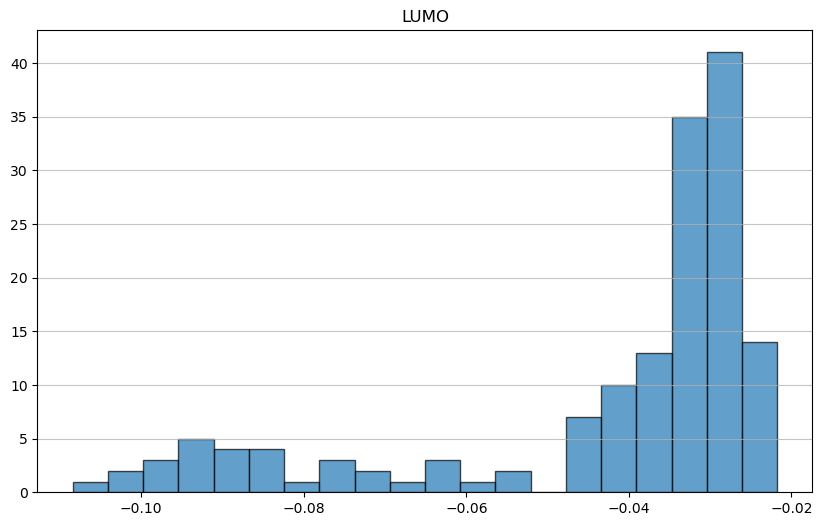

pvalue LUMO: 1.2210912996071442e-15


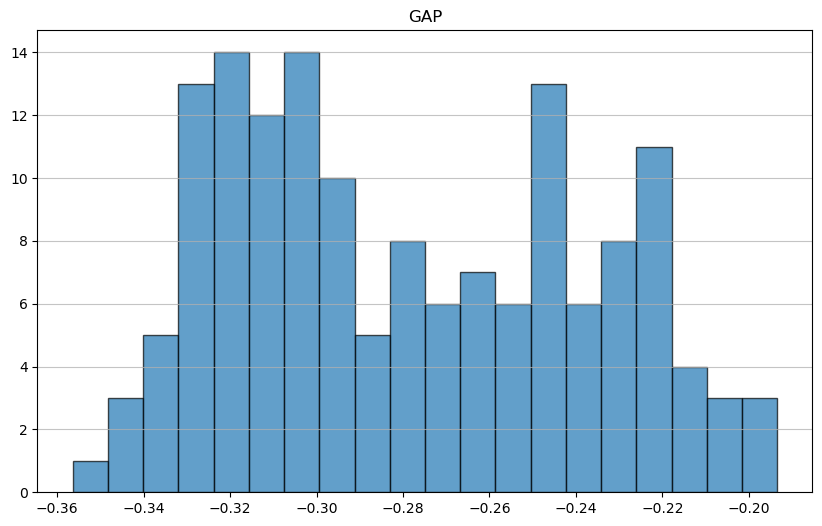

pvalue GAP: 5.1080563531168695e-05


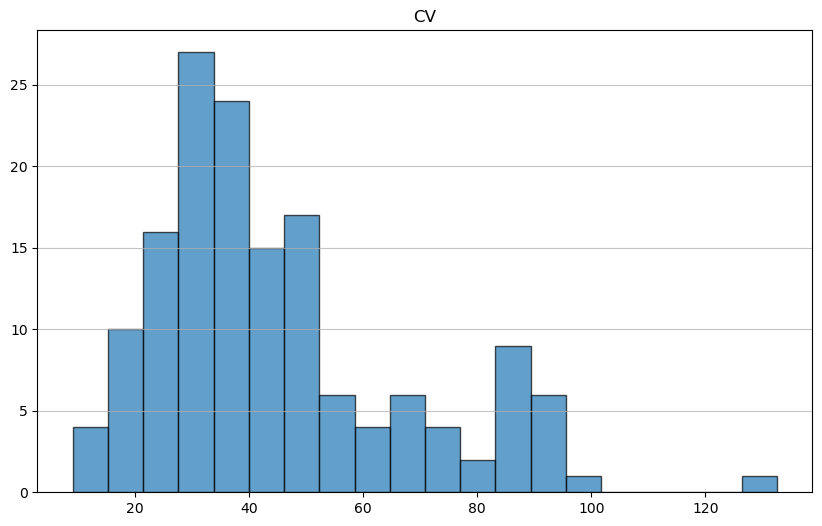

pvalue CV: 1.0326895884726762e-08


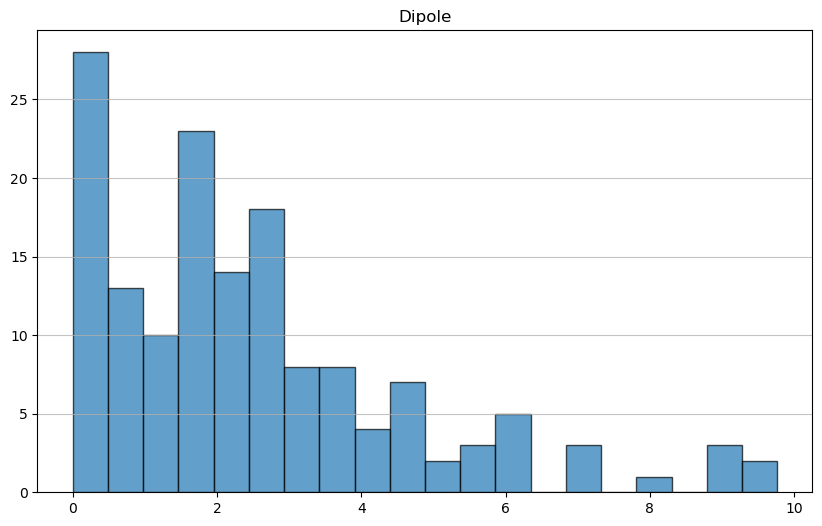

pvalue Dipole: 2.0945716070673565e-09


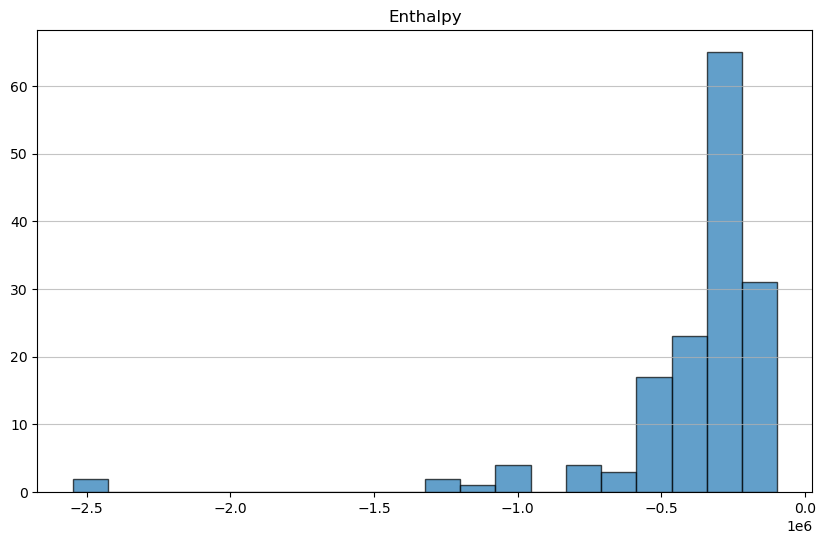

pvalue Enthalpy: 9.109348168374505e-19


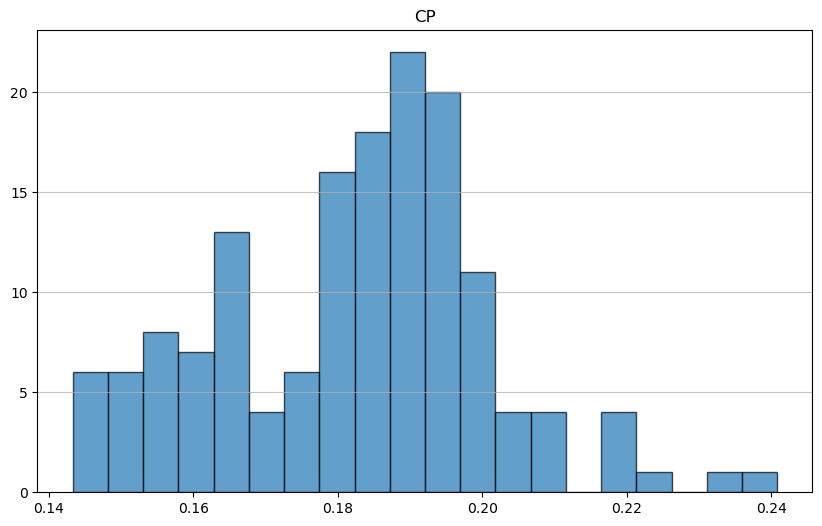

pvalue CP: 0.0031266080734458695


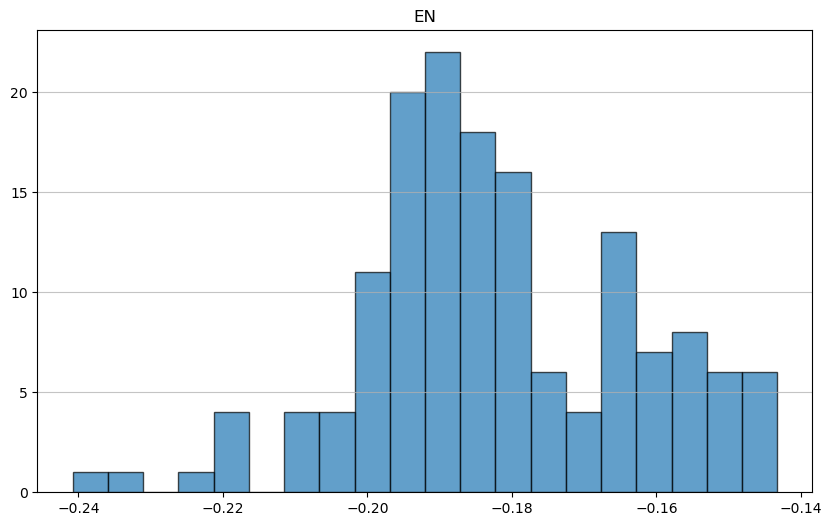

pvalue EN: 0.0031266080734464255


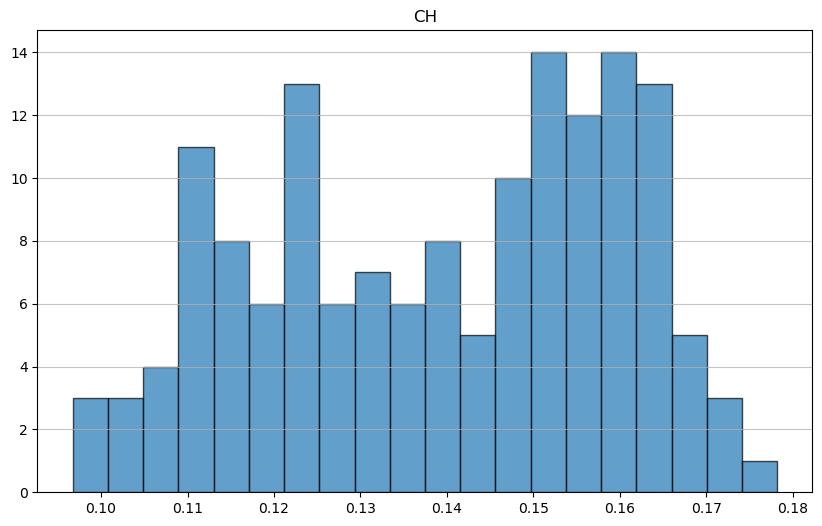

pvalue CH: 5.1080563531174374e-05


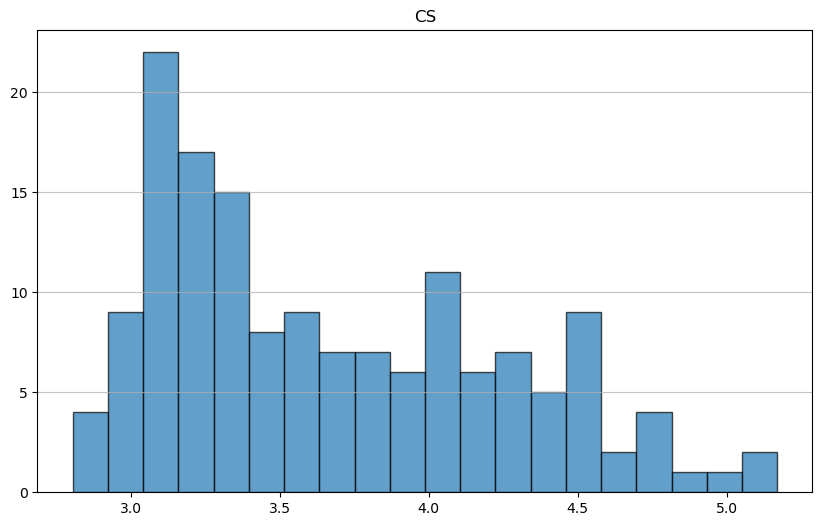

pvalue CS: 6.783340322834005e-07


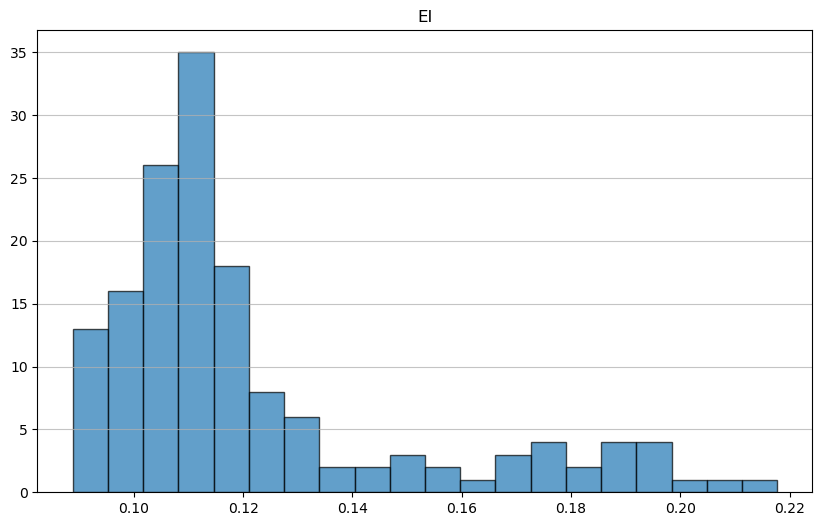

pvalue EI: 1.4116074499233907e-13


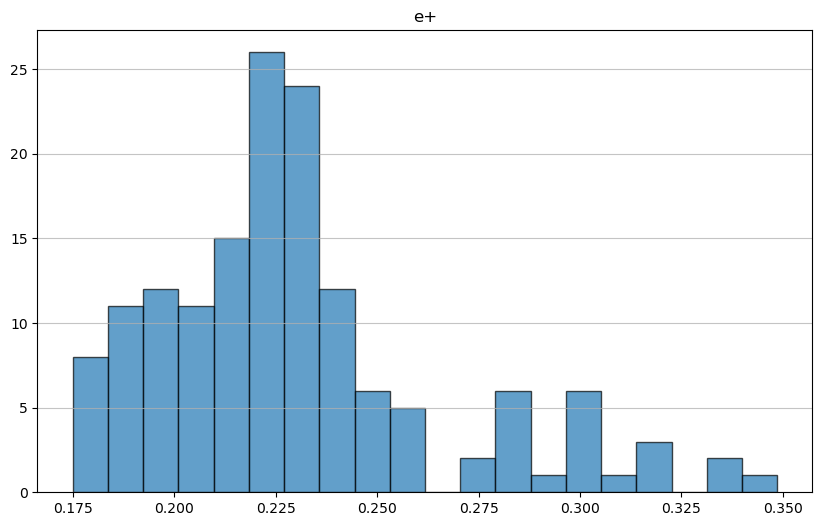

pvalue e+: 4.1450129044015725e-08


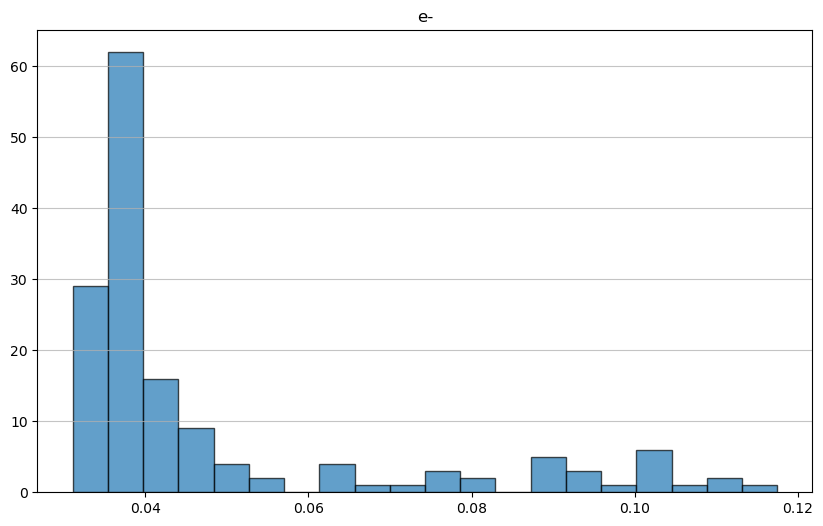

pvalue e-: 6.160039142020795e-17


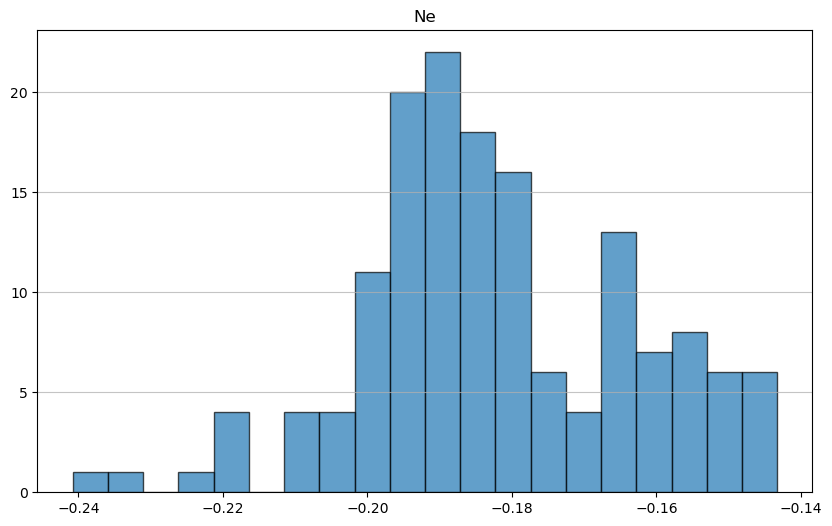

pvalue Ne: 0.0031266080734461557


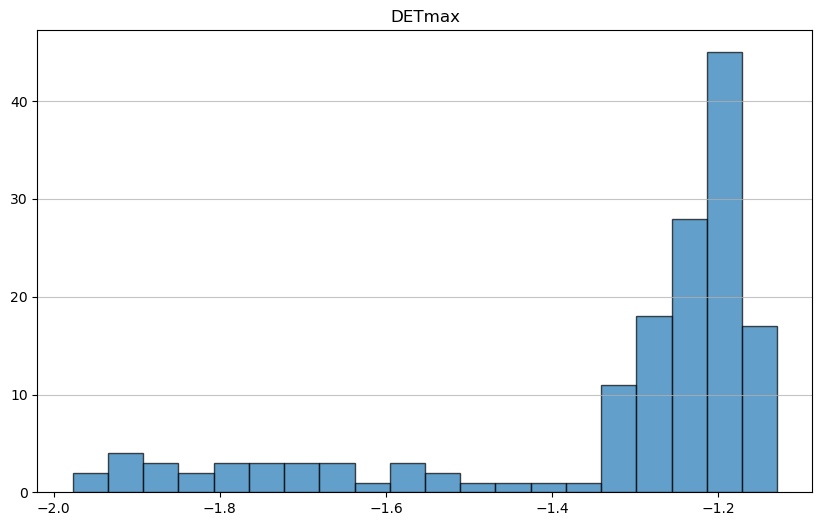

pvalue DETmax: 6.832330186894059e-16


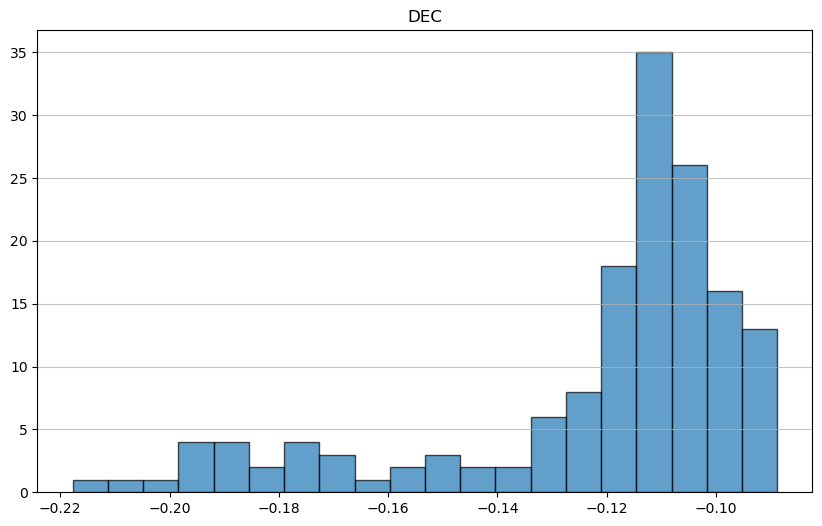

pvalue DEC: 1.4116074499234624e-13


In [16]:
features = ['HOMO', 'LUMO', 'GAP', 'CV', 'Dipole', 'Enthalpy', 'CP', 'EN', 'CH', 'CS', 'EI', 'e+', 'e-', 'Ne', 'DETmax', 'DEC']

for feature in features:
    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.hist(df[feature], bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(feature)
    ax.grid(axis='y', alpha=0.75)
    plt.show()

    _, pvalue = stats.shapiro(df[feature])

    print(f"pvalue {feature}: {pvalue}")

## Correlation

✅ Gráficos salvos em PNG e SVG na pasta:
C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures


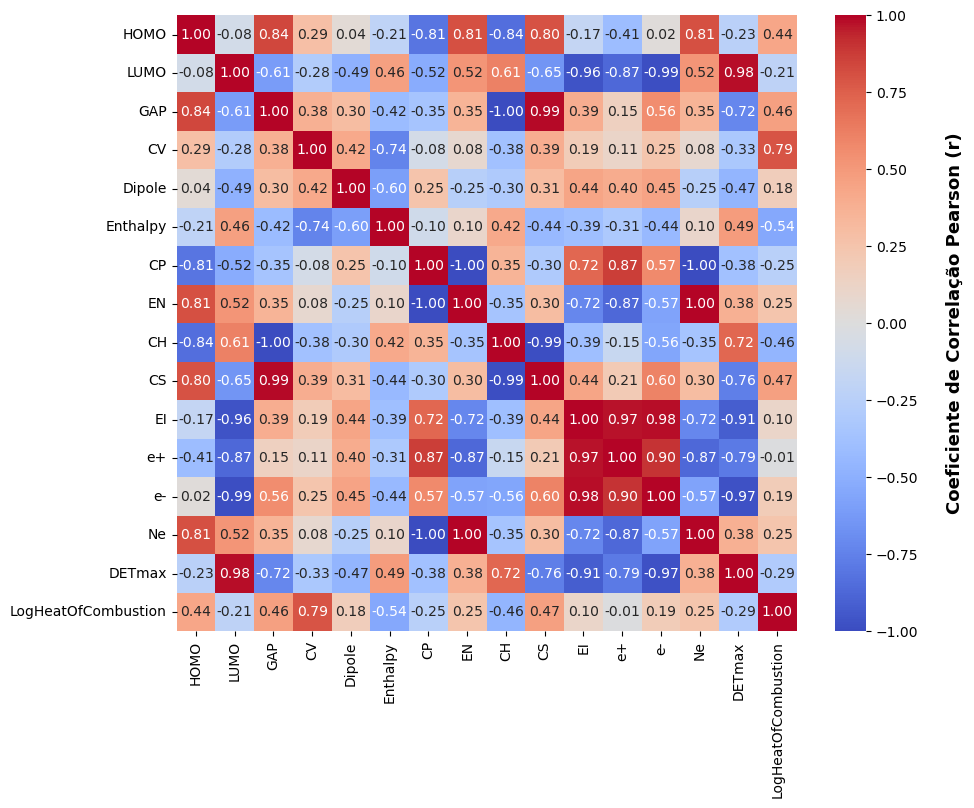

In [17]:
all_features = ['HOMO', 'LUMO', 'GAP', 'CV', 'Dipole', 'Enthalpy', 'CP', 'EN', 'CH', 'CS', 'EI', 'e+', 'e-', 'Ne', 'DETmax']


correlation_matrix = df[all_features+['LogHeatOfCombustion']].corr(numeric_only=True)

fig = plt.figure(figsize=(10, 8))
ax = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# 2. Configura o rótulo da barra lateral com negrito e tamanho específico
ax.collections[0].colorbar.set_label('Coeficiente de Correlação Pearson (r)', fontweight='bold', fontsize=13, labelpad=20)
#plt.title('Heatmap de Correlação entre as Variáveis')


#EXPORTAR IMAGEM EM PNG, SVG E PDF

name_arq = "heatmap-all"
caminho = r"C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures"
caminho_completo = os.path.join(caminho, name_arq)

# 1. Salvar PNG (Alta Resolução)
caminho_png = os.path.join(caminho, name_arq + ".png")
fig.savefig(caminho_png, dpi=600, bbox_inches='tight', facecolor='white')

# 2. Salvar SVG (VETORIAL - Para Inkscape/Edição)
caminho_svg = os.path.join(caminho, name_arq + ".svg")
fig.savefig(caminho_svg, format='svg', bbox_inches='tight', facecolor='white')

print(f"✅ Gráficos salvos em PNG e SVG na pasta:\n{caminho}")



plt.show()

✅ Gráficos salvos em PNG e SVG na pasta:
C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures


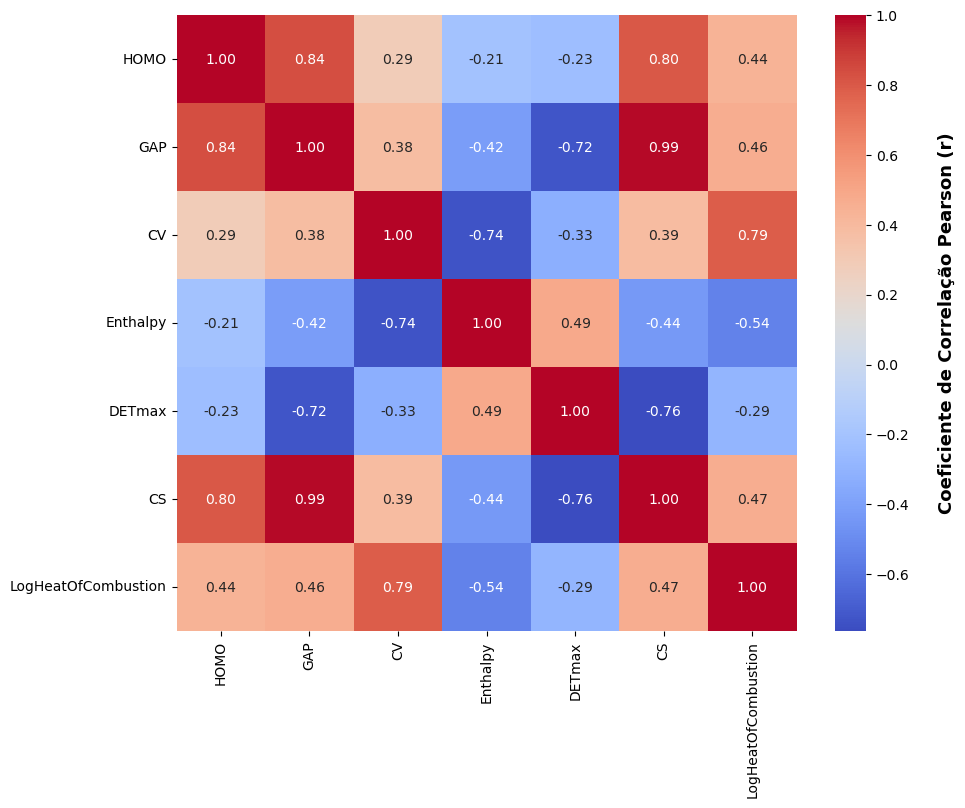

In [18]:
work_features = ['HOMO', "GAP", "CV", 'Enthalpy',  'DETmax', 'CS' ]

correlation_matrix =df[work_features+['LogHeatOfCombustion']].corr(numeric_only=True)

fig = plt.figure(figsize=(10, 8))
ax = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# 2. Configura o rótulo da barra lateral com negrito e tamanho específico
ax.collections[0].colorbar.set_label('Coeficiente de Correlação Pearson (r)', fontweight='bold', fontsize=13, labelpad=20)
#plt.title('Heatmap de Correlação entre as Variáveis')
plt.xticks(rotation=90)
plt.yticks(rotation=0)


#EXPORTAR IMAGEM EM PNG, SVG E PDF

name_arq = "heatmap-selected"
caminho = r"C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures"
caminho_completo = os.path.join(caminho, name_arq)

# 1. Salvar PNG (Alta Resolução)
caminho_png = os.path.join(caminho, name_arq + ".png")
fig.savefig(caminho_png, dpi=600, bbox_inches='tight', facecolor='white')

# 2. Salvar SVG (VETORIAL - Para Inkscape/Edição)
caminho_svg = os.path.join(caminho, name_arq + ".svg")
fig.savefig(caminho_svg, format='svg', bbox_inches='tight', facecolor='white')

print(f"✅ Gráficos salvos em PNG e SVG na pasta:\n{caminho}")





plt.show()

In [19]:
df[work_features + ["LogHeatOfCombustion"]].corr()['LogHeatOfCombustion'].drop("LogHeatOfCombustion")


HOMO        0.437107
GAP         0.463464
CV          0.790386
Enthalpy   -0.542744
DETmax     -0.293895
CS          0.465784
Name: LogHeatOfCombustion, dtype: float64

## Adding Classes

In [20]:
hierarquia_smarts = [
    # 1. NITROGENADOS, ENXOFRE E HALOGENADOS
    ('compostos nitro', '[N+](=O)[O-]'),
    ('sulfonamidas', '[#16H0](=[OX1])(=[OX1])-[#7]'),
    ('nitrilas', '[C]#[N]'),
    ('amidas', '[NX3][CX3](=[OX1])'),
    ('aminas', '[NX3;H2,H1,H0;!$(NC=O)]'),
    ('compostos halogenados', '[F,Cl,Br,I]'),

    # 2. HETEROCICLOS (Anéis com heteroátomos)
    # n, o, s em minúsculo no SMARTS representam átomos aromáticos em anéis
    ('heterociclos nitrogenados', '[n,N]1~[c,C,n,N]~[c,C,n,N]~[c,C,n,N]~[c,C,n,N]~1'), # Ex: Piridina, Pirrol
    ('heterociclos oxigenados', '[o,O]1~[c,C,o,O]~[c,C,o,O]~[c,C,o,O]~[c,C,o,O]~1'),    # Ex: Furano, Tetrahidrofuran
    ('heterociclos sulfurados', '[s,S]1~[c,C,s,S]~[c,C,s,S]~[c,C,s,S]~[c,C,s,S]~1'),    # Ex: Tiofeno
    
    # 3. OXIGENADOS ESPECÍFICOS E COMPLEXOS
    ('acetais', '[CX4](OC)(OC)'),
    ('anidridos de ácido', '[CX3](=[OX1])[OX2][CX3](=[OX1])'),
    ('ácidos carboxílicos', '[CX3](=O)[OX2H1]'),
    ('ésteres', '[CX3](=O)[OX2H0][#6]'),
    ('quinonas', '[#6]1(=O)[#6]=[#6][#6](=O)[#6]=[#6]1'),
    ('fenóis', '[OX2H]c1ccccc1'),
    ('epóxidos', '[C]1[O][C]1'),
    
    # 4. OXIGENADOS GERAIS
    ('aldeídos', '[CX3H1](=O)'),
    ('cetonas', '[#6][CX3](=O)[#6]'),
    ('álcoois', '[OX2H][CX4]'),
    ('éteres', '[#6][OD2][#6]'),
    
    # 5. HIDROCARBONETOS (Apenas C e H)
    ('hidrocarbonetos aromáticos', 'c1ccccc1'),
    ('hidrocarbonetos insaturados', '[C]#[C]'), #ligação tripla
    ('hidrocarbonetos insaturados', '[C]=[C]'),  #ligação dupla
]

padoes_compilados = []
for nome, smarts in hierarquia_smarts:
    p = Chem.MolFromSmarts(smarts)
    if p is None:
        print(f"Aviso: SMARTS inválido ignorado: {nome} -> {smarts}")
    else:
        padoes_compilados.append((nome, p))

In [21]:
def classificar_molecula_rdkit(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return "SMILES Inválido"
    
    nomes = []
    
    for nome, padrao in padoes_compilados:
        if mol.HasSubstructMatch(padrao):
            nomes.append(nome)


    atomos = {atom.GetSymbol() for atom in mol.GetAtoms()}
    if atomos <= {'C', 'H'}:
        nomes.append('hidrocarbonetos saturados')

    if len(nomes) > 0:
        return ';'.join(set(nomes))

    return "outros"


df['classes'] = df['SMILES'].apply(classificar_molecula_rdkit)


C:\Users\User\AppData\Local\Temp\ipykernel_13272\3864600751.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['classes'] = df['SMILES'].apply(classificar_molecula_rdkit)


In [22]:
import pandas as pd
from rdkit import Chem

classes_unicas = sorted(list(set(nome for nome, _ in hierarquia_smarts)))

def mapear_classes_binario(smiles):
    mol = Chem.MolFromSmiles(smiles)
    
    # Criamos um dicionário inicial com todas as classes zeradas
    
    resultado = {f"classe_{nome}": 0 for i, nome in enumerate(classes_unicas)}
    
    hid_sat_col = f"classe_hidrocarbonetos saturados"
    resultado[hid_sat_col] = 0
    
    outros_col = f"classe_outros"
    resultado[outros_col] = 0
    
    
    if not mol:
        return resultado # Retorna tudo zero se o SMILES for inválido

    encontrou_alguma = False

    ## Buscando nos padrões   
    for nome, padrao in padoes_compilados:
        if mol.HasSubstructMatch(padrao):
            resultado[f"classe_{nome}"] = 1
            encontrou_alguma = True
            
    ## Buscando hidrocarbonetos saturados
    atomos = {atom.GetSymbol() for atom in mol.GetAtoms()}
    if atomos <= {'C', 'H'}:
        resultado[hid_sat_col] = 1
        encontrou_alguma = True

    ## Atribuindo Outros a quem nao tem classe
    if not encontrou_alguma:
        resultado[outros_col] = 1
            
    return resultado

df_one_hot_encoding = df['SMILES'].apply(mapear_classes_binario).apply(pd.Series)
df = pd.concat([df, df_one_hot_encoding], axis=1)
one_hot_encoding_classes_cols = list(df_one_hot_encoding.columns)


## Modeling

In [23]:
from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# RDKit for fingerprints
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys

# SHAP for interpretability
import shap

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [24]:
def get_models():
    """Define models to test"""
    models = {
        'Random Forest': RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=100,
            max_depth=5,
            random_state=42
        ),
        # 'SVR': SVR(
        #     kernel='rbf',
        #     C=10,
        #     gamma='scale'
        # ),
        'PLS': PLSRegression(
            n_components=5,
            scale=False  # já fazemos o scaling externamente
        ),
        'Ridge': Ridge(
            alpha=1.0,
            random_state=42
        ),
        'Lasso': Lasso(
            alpha=0.1,
            random_state=42,
            max_iter=10000
        ),
        'ElasticNet': ElasticNet(
            alpha=0.1,
            l1_ratio=0.5,
            random_state=42,
            max_iter=10000
        ),
        # 'KNN': KNeighborsRegressor(
        #     n_neighbors=5,
        #     weights='distance'
        # ),
        # 'Decision Tree': DecisionTreeRegressor(
        #     max_depth=10,
        #     random_state=42
        # ),
        # 'Neural Network': MLPRegressor(
        #     hidden_layer_sizes=(100, 50),
        #     max_iter=1000,
        #     random_state=42,
        #     early_stopping=True
        # )
    }
    return models

print("✓ Models defined:")
for name in get_models().keys():
    print(f"  - {name}")

✓ Models defined:
  - Random Forest
  - Gradient Boosting
  - PLS
  - Ridge
  - Lasso
  - ElasticNet


In [25]:
def train_and_evaluate_loocv(x, y, model_name, strategy_name, scale=True):
    """
    Treina e avalia via Leave-One-Out Cross-Validation (LOOCV).

    ⚠️ Nota importante sobre escala:
    - 'y' é o alvo NA ESCALA DO MODELO:
        * se target_scale == "log"  -> y = ln(HC)
        * se target_scale == "raw"  -> y = HC
    - Além das métricas nessa escala, esta função também calcula métricas na escala física (HC em kJ/mol),
      invertendo a transformação via y_inverse().

    Retorna (dicionário):
      - métricas na escala do modelo (r2_train, q2_loocv, rmse_loocv, mae_loocv, rmse_train, mae_train)
      - métricas na escala HC (r2_train_hc, q2_loocv_hc, rmse_loocv_hc, mae_loocv_hc, rmse_train_hc, mae_train_hc)
      - vetores y_true/y_pred (escala do modelo) e y_true_hc/y_pred_hc (escala física)
      - modelo treinado + scaler (se aplicável)
    """
    print(f"\n{'='*80}")
    print(f"Training: {model_name} | Strategy: {strategy_name}")
    print(f"{'='*80}")

    # Scale features if needed
    # antigo: o notebook escalava X fora do CV (pode introduzir leakage).
    # novo: mantemos isso para NÃO alterar a metodologia original do notebook.
    #       Para uma validação mais rigorosa, vamos adicionar depois repeated k-fold com Pipeline.
    if scale:
        scaler = StandardScaler()
        x_scaled = scaler.fit_transform(x)
    else:
        x_scaled = x
        scaler = None

    # Get model
    models_dict = get_models()
    model = models_dict[model_name]

    # LOOCV
    loo = LeaveOneOut()

    # Cross-validation predictions (Q²)
    y_pred_cv = cross_val_predict(model, x_scaled, y, cv=loo)

    # Train on full dataset for R² (e erros de treino)
    model.fit(x_scaled, y)
    y_pred_train = model.predict(x_scaled)

    # Garantir 1D (ex.: PLSRegression pode retornar (n,1))
    y_pred_cv = np.asarray(y_pred_cv).ravel()
    y_pred_train = np.asarray(y_pred_train).ravel()

    # ===== métricas na escala do MODELO (log ou raw) =====
    r2_train = r2_score(y, y_pred_train)
    q2_loocv = r2_score(y, y_pred_cv)  # Q² = R² em predições LOOCV
    rmse_loocv = np.sqrt(mean_squared_error(y, y_pred_cv))
    mae_loocv = mean_absolute_error(y, y_pred_cv)

    # novo: também computar erros de treino (gap numérico)
    rmse_train = np.sqrt(mean_squared_error(y, y_pred_train))
    mae_train = mean_absolute_error(y, y_pred_train)

    # ===== inversão para HC (kJ/mol) e métricas na escala física =====
    # antigo: os gráficos/métricas eram reportados em ln(HC).
    # novo: sempre produzimos versões em HC via y_inverse().
    y_true_hc = y_inverse(y)
    y_pred_cv_hc = y_inverse(y_pred_cv)
    y_pred_train_hc = y_inverse(y_pred_train)

    r2_train_hc = r2_score(y_true_hc, y_pred_train_hc)
    q2_loocv_hc = r2_score(y_true_hc, y_pred_cv_hc)
    rmse_loocv_hc = np.sqrt(mean_squared_error(y_true_hc, y_pred_cv_hc))
    mae_loocv_hc = mean_absolute_error(y_true_hc, y_pred_cv_hc)

    rmse_train_hc = np.sqrt(mean_squared_error(y_true_hc, y_pred_train_hc))
    mae_train_hc = mean_absolute_error(y_true_hc, y_pred_train_hc)

    print(f"\n📊 RESULTS (escala do modelo: {'ln(HC)' if target_scale=='log' else 'HC'})")
    print(f"   R² (training): {r2_train:.4f}")
    print(f"   Q² (LOOCV):    {q2_loocv:.4f}")
    print(f"   RMSE (LOOCV):  {rmse_loocv:.6f}")
    print(f"   MAE  (LOOCV):  {mae_loocv:.6f}")
    print(f"   RMSE (train):  {rmse_train:.6f}")
    print(f"   MAE  (train):  {mae_train:.6f}")

    print(f"\n📌 RESULTS (escala física: HC em kJ/mol)")
    print(f"   R²_hc (training): {r2_train_hc:.4f}")
    print(f"   Q²_hc (LOOCV):    {q2_loocv_hc:.4f}")
    print(f"   RMSE_hc (LOOCV):  {rmse_loocv_hc:.3f} kJ/mol")
    print(f"   MAE_hc  (LOOCV):  {mae_loocv_hc:.3f} kJ/mol")
    print(f"   RMSE_hc (train):  {rmse_train_hc:.3f} kJ/mol")
    print(f"   MAE_hc  (train):  {mae_train_hc:.3f} kJ/mol")

    results = {
        'model': model_name,
        'strategy': strategy_name,

        # escala do modelo
        'r2_train': r2_train,
        'q2_loocv': q2_loocv,
        'rmse_loocv': rmse_loocv,
        'mae_loocv': mae_loocv,
        'rmse_train': rmse_train,
        'mae_train': mae_train,

        # escala física (HC)
        'r2_train_hc': r2_train_hc,
        'q2_loocv_hc': q2_loocv_hc,
        'rmse_loocv_hc': rmse_loocv_hc,
        'mae_loocv_hc': mae_loocv_hc,
        'rmse_train_hc': rmse_train_hc,
        'mae_train_hc': mae_train_hc,

        # vetores (modelo e HC)
        'y_true': y,
        'y_pred_train': y_pred_train,
        'y_pred_cv': y_pred_cv,
        'y_true_hc': y_true_hc,
        'y_pred_train_hc': y_pred_train_hc,
        'y_pred_cv_hc': y_pred_cv_hc,

        # artefatos do treino
        'trained_model': model,
        'scaler': scaler,
        'x_scaled': x_scaled
    }

    return results

print("✓ Training function defined")


✓ Training function defined


In [26]:
# antigo: X = df[work_features].values
# novo: usamos 'x' em minúsculo (mesma coisa, só padronização)
x = df[work_features].values

# antigo: y = df['LogHeatOfCombustion'].values  (sempre em ln(HC))
# novo: você escolhe a escala do alvo via 'target_scale'
if target_scale == "log":
    y = df['LogHeatOfCombustion'].values  # ln(HC)
elif target_scale == "raw":
    y = df['HeatOfCombustion'].values     # HC (kJ/mol)
else:
    raise ValueError("target_scale inválido: use 'log' ou 'raw'")

all_results = []

for model_name in get_models().keys():
    results = train_and_evaluate_loocv(
        x, y, model_name, 'DFT Only', scale=True
    )
    all_results.append(results)



Training: Random Forest | Strategy: DFT Only



📊 RESULTS (escala do modelo: ln(HC))
   R² (training): 0.9659
   Q² (LOOCV):    0.7456
   RMSE (LOOCV):  0.270207
   MAE  (LOOCV):  0.199101
   RMSE (train):  0.098908
   MAE  (train):  0.073241

📌 RESULTS (escala física: HC em kJ/mol)
   R²_hc (training): 0.9545
   Q²_hc (LOOCV):    0.7360
   RMSE_hc (LOOCV):  1468.580 kJ/mol
   MAE_hc  (LOOCV):  947.239 kJ/mol
   RMSE_hc (train):  609.536 kJ/mol
   MAE_hc  (train):  357.784 kJ/mol

Training: Gradient Boosting | Strategy: DFT Only

📊 RESULTS (escala do modelo: ln(HC))
   R² (training): 0.9997
   Q² (LOOCV):    0.7230
   RMSE (LOOCV):  0.281974
   MAE  (LOOCV):  0.201747
   RMSE (train):  0.008936
   MAE  (train):  0.007183

📌 RESULTS (escala física: HC em kJ/mol)
   R²_hc (training): 0.9997
   Q²_hc (LOOCV):    0.6714
   RMSE_hc (LOOCV):  1638.574 kJ/mol
   MAE_hc  (LOOCV):  977.342 kJ/mol
   RMSE_hc (train):  49.061 kJ/mol
   MAE_hc  (train):  36.897 kJ/mol

Training: PLS | Strategy: DFT Only

📊 RESULTS (escala do modelo: ln(HC))
  

In [27]:
# antigo: X = df[work_features + one_hot_encoding_classes_cols].values
# novo: 'x' em minúsculo (features DFT + classes)
x = df[work_features + one_hot_encoding_classes_cols].values

# antigo: y = df['LogHeatOfCombustion'].values
# novo: controlado por 'target_scale'
if target_scale == "log":
    y = df['LogHeatOfCombustion'].values  # ln(HC)
elif target_scale == "raw":
    y = df['HeatOfCombustion'].values     # HC (kJ/mol)
else:
    raise ValueError("target_scale inválido: use 'log' ou 'raw'")

for model_name in get_models().keys():
    results = train_and_evaluate_loocv(
        x, y, model_name, 'DFT + One-Hot Encoding Classes', scale=True
    )
    all_results.append(results)



Training: Random Forest | Strategy: DFT + One-Hot Encoding Classes

📊 RESULTS (escala do modelo: ln(HC))
   R² (training): 0.9695
   Q² (LOOCV):    0.7776
   RMSE (LOOCV):  0.252640
   MAE  (LOOCV):  0.176367
   RMSE (train):  0.093531
   MAE  (train):  0.065751

📌 RESULTS (escala física: HC em kJ/mol)
   R²_hc (training): 0.9555
   Q²_hc (LOOCV):    0.7467
   RMSE_hc (LOOCV):  1438.621 kJ/mol
   MAE_hc  (LOOCV):  855.342 kJ/mol
   RMSE_hc (train):  603.171 kJ/mol
   MAE_hc  (train):  322.054 kJ/mol

Training: Gradient Boosting | Strategy: DFT + One-Hot Encoding Classes

📊 RESULTS (escala do modelo: ln(HC))
   R² (training): 0.9998
   Q² (LOOCV):    0.7443
   RMSE (LOOCV):  0.270903
   MAE  (LOOCV):  0.179196
   RMSE (train):  0.007553
   MAE  (train):  0.006041

📌 RESULTS (escala física: HC em kJ/mol)
   R²_hc (training): 0.9997
   Q²_hc (LOOCV):    0.6725
   RMSE_hc (LOOCV):  1635.836 kJ/mol
   MAE_hc  (LOOCV):  882.192 kJ/mol
   RMSE_hc (train):  48.880 kJ/mol
   MAE_hc  (train):  

In [28]:
# antigo: df_results = ... [["model", ...]]  -> isso descartava colunas essenciais (trained_model, y_pred_*, etc.)
# novo (v3): mantemos df_results COMPLETO e criamos um df_results_view só para visualização.
# mudança solicitada: ranquear a tabela pelo q2_loocv (escala do modelo = ln(HC)), mas manter os gráficos na escala física (HC).

df_results = pd.DataFrame(all_results).reset_index(drop=True)

# df_results = df_results.sort_values(by='q2_loocv_hc', ascending=False)
# novo: ranking pelo q2_loocv (ln(HC)) para comparar desempenho no espaço em que o modelo foi ajustado/avaliado.
df_results = df_results.sort_values(by='q2_loocv', ascending=False).reset_index(drop=True)

# métricas auxiliares de diagnóstico (overfitting)
df_results['r2_q2_dif'] = df_results['r2_train'] - df_results['q2_loocv']
df_results['r2_q2_dif_hc'] = df_results['r2_train_hc'] - df_results['q2_loocv_hc']

# gaps em erro na escala física (HC, kJ/mol) -> úteis para interpretar overfitting em termos físicos
df_results['rmse_gap_hc'] = df_results['rmse_loocv_hc'] - df_results['rmse_train_hc']
df_results['mae_gap_hc'] = df_results['mae_loocv_hc'] - df_results['mae_train_hc']


# para ranquear e comparar generalização:
# - q2_loocv (escala ln(HC)
# - rmse_loocv / mae_loocv (escala ln(HC)) -> erro relativo ao espaço onde o modelo otimiza
# essenciais para interpretação física (gráficos em HC):
# - q2_loocv_hc, rmse_loocv_hc, mae_loocv_hc (kJ/mol)
# essenciais para suspeita de overfitting:
# - r2_q2_dif / r2_q2_dif_hc (gap em R² vs Q²)
# - rmse_gap_hc / mae_gap_hc (gap em erro físico: validação - treino)

cols_essenciais = [
    "model", "strategy",
    "q2_loocv", "rmse_loocv", "mae_loocv",
    "q2_loocv_hc", "rmse_loocv_hc", "mae_loocv_hc",
    "r2_q2_dif", "r2_q2_dif_hc",
    "rmse_gap_hc", "mae_gap_hc",

    # NÃO essenciais:
    # "r2_train",         
    # "rmse_train",        # (escala do modelo)
    # "mae_train",         #  (escala do modelo)
    # "r2_train_hc",       #  (escala física)
    # "rmse_train_hc",     #  (escala física)
    # "mae_train_hc",      #  (escala física)
]

df_results_view = df_results[cols_essenciais].copy()
df_results_view


,model,strategy,q2_loocv,rmse_loocv,mae_loocv,q2_loocv_hc,rmse_loocv_hc,mae_loocv_hc,r2_q2_dif,r2_q2_dif_hc,rmse_gap_hc,mae_gap_hc
0,Ridge,DFT + One-Hot Encoding Classes,0.781929,0.250190,0.183002,0.652162,1685.759352,989.260553,0.071913,0.167997,473.622633,224.963663
1,Random Forest,DFT + One-Hot Encoding Classes,0.777638,0.252640,0.176367,0.746674,1438.621304,855.341549,0.191885,0.208794,835.449984,533.287807
2,PLS,DFT + One-Hot Encoding Classes,0.771839,0.255913,0.189199,0.665664,1652.715911,1006.987358,0.063576,0.129479,359.020230,176.047713
3,Random Forest,DFT Only,0.745640,0.270207,0.199101,0.736014,1468.580287,947.239171,0.220279,0.218510,859.044768,589.455038
4,Gradient Boosting,DFT + One-Hot Encoding Classes,0.744326,0.270903,0.179196,0.672459,1635.836093,882.191875,0.255475,0.327249,1586.956423,849.542467
5,Gradient Boosting,DFT Only,0.723004,0.281974,0.201747,0.671361,1638.574091,977.341816,0.276718,0.328344,1589.512756,940.444741
6,ElasticNet,DFT + One-Hot Encoding Classes,0.697064,0.294881,0.230448,0.656961,1674.090302,1152.252981,0.034510,0.049572,125.678484,66.597572
7,Ridge,DFT Only,0.642798,0.320205,0.250136,0.462207,2096.111999,1275.989095,0.038593,0.119970,248.531962,84.270932
8,ElasticNet,DFT Only,0.633940,0.324151,0.263111,0.583264,1845.174167,1306.359397,0.019089,0.039975,90.728408,40.581189
9,PLS,DFT Only,0.626230,0.327547,0.250335,0.407250,2200.607775,1289.851714,0.067938,0.190716,388.273057,133.370316


In [29]:
#df_results.iloc[0]["trained_model"].predict()
df_results.iloc[0]["trained_model"]

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


### COMPARAÇÃO VISUAL: GRÁFICO DUMBBELL (DFT vs DFT + CLASSES)

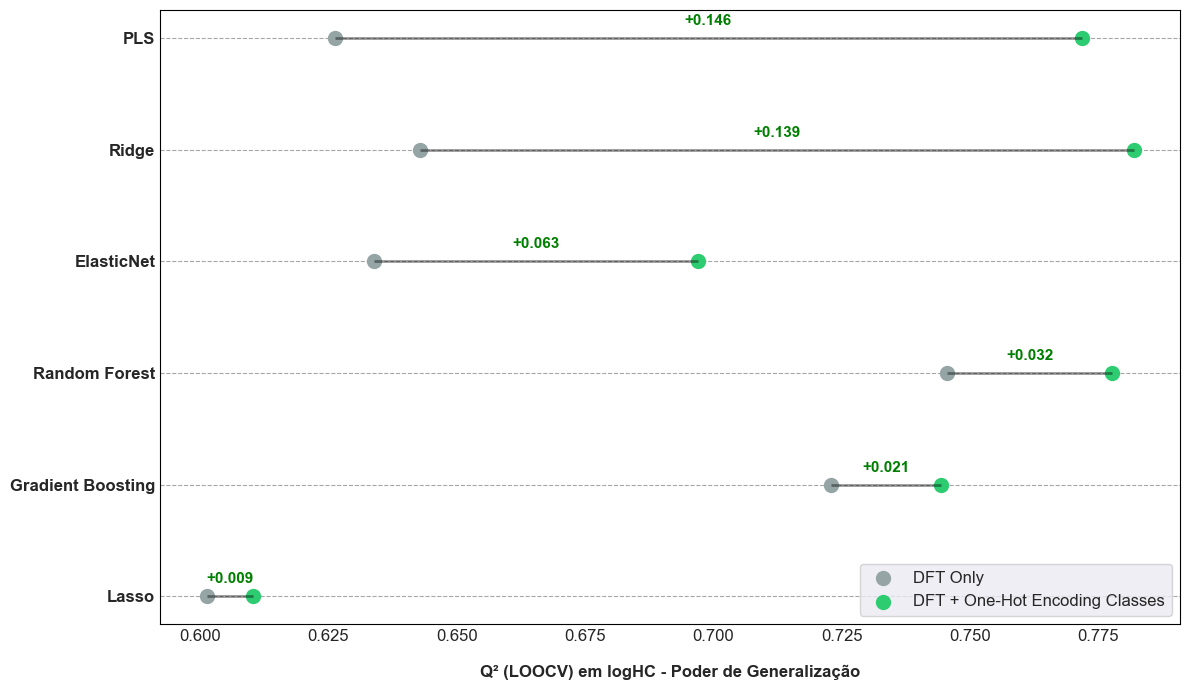

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Preparação dos Dados (Pivotagem)
# antigo: df_plot = df_results.pivot(index='model', columns='strategy', values='q2_loocv')  # Q² em ln(HC)
# novo: usamos Q² na escala física (HC), calculado por q2_loocv_hc
df_plot = df_results.pivot(index='model', columns='strategy', values='q2_loocv')

# Identificar automaticamente os nomes das colunas (estratégias)
cols = df_plot.columns.tolist()
cols.sort(key=lambda x: len(x)) 
col_dft = cols[0]
col_class = cols[1]

# Calcular o ganho para ordenar o gráfico
df_plot['ganho'] = df_plot[col_class] - df_plot[col_dft]
df_plot = df_plot.sort_values('ganho', ascending=True)

# 2. Configuração do Gráfico
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_facecolor('white')
ax.grid(axis='y', linestyle='--', alpha=0.7, color='gray')

color_dft = '#95a5a6'
color_class = '#2ecc71'

y_range = range(len(df_plot))

# 3. Linha conectora
ax.hlines(y=y_range, xmin=df_plot[col_dft], xmax=df_plot[col_class], 
          color='black', alpha=0.4, linewidth=2)

# 4. Pontos
ax.scatter(df_plot[col_dft], y_range, color=color_dft, alpha=1, s=100, label=col_dft)
ax.scatter(df_plot[col_class], y_range, color=color_class, alpha=1, s=100, label=col_class)

# 5. Anotações de ganho
for i, (idx, row) in enumerate(df_plot.iterrows()):
    diff = row[col_class] - row[col_dft]
    mid_point = (row[col_dft] + row[col_class]) / 2
    ax.text(mid_point, i + 0.15, f'+{diff:.3f}', 
            ha='center', va='center', color='green', fontweight='bold', fontsize=11)

# 6. Cosmética
ax.set_yticks(list(y_range))
ax.set_yticklabels(df_plot.index, fontweight='bold', fontsize=11)

# antigo: ax.set_xlabel('Q² (LOOCV) - Poder de Generalização', ...)
# novo: deixa explícito que o Q² foi calculado em HC (kJ/mol)
ax.set_xlabel('Q² (LOOCV) em logHC - Poder de Generalização', 
              fontsize=12, fontweight='bold', labelpad=15)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8)

ax.tick_params(axis="x", labelsize=12)  # tamanho dos números no eixo x
ax.tick_params(axis="y", labelsize=12)  # tamanho dos números no eixo y

ax.legend(loc='lower right', frameon=True, fontsize=12)

caminho = r"C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures"
fig.savefig(os.path.join(caminho, "Dumbbell_Comparacao_Q2_em_logHC.png"), dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(caminho, "Dumbbell_Comparacao_Q2_em_logHC.svg"), format='svg', bbox_inches='tight', facecolor='white')

plt.tight_layout()
plt.show()


In [31]:
df.to_excel(r'C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\database\data/data_models.xlsx')

In [32]:
df_results.to_excel(r'C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\database\data\model_performance.xlsx')

## Predictions with Best Model

In [33]:
# Get best model and its data (como estava no notebook)
best_model_data = df_results.iloc[0]
best_model = best_model_data['trained_model']
best_strategy = best_model_data['strategy']
best_model_name = best_model_data['model']

print(f"Best Model (por Q² na escala do modelo): {best_model_name}")
print(f"Strategy: {best_strategy}")
print(f"Q² (LOOCV, escala do modelo): {best_model_data['q2_loocv']:.4f}")
print(f"R² (training, escala do modelo): {best_model_data['r2_train']:.4f}")
print(f"RMSE (LOOCV, escala do modelo): {best_model_data['rmse_loocv']:.4f}")
print(f"MAE  (LOOCV, escala do modelo): {best_model_data['mae_loocv']:.4f}")

print("\n--- Métricas do MESMO modelo na escala física (HC) ---")
print(f"Q² (LOOCV, HC): {best_model_data['q2_loocv_hc']:.4f}")
print(f"R² (training, HC): {best_model_data['r2_train_hc']:.4f}")
print(f"RMSE (LOOCV, HC): {best_model_data['rmse_loocv_hc']:.2f} kJ/mol")
print(f"MAE  (LOOCV, HC): {best_model_data['mae_loocv_hc']:.2f} kJ/mol")


# =========================
# Seleção explícita do Ridge 
# =========================

ridge_dft_match = df_results[(df_results['model'] == 'Ridge') & (df_results['strategy'] == 'DFT Only')]
if len(ridge_dft_match) == 0:
    raise ValueError("Não encontrei 'Ridge' com strategy == 'DFT Only' em df_results.")
ridge_dft_data = ridge_dft_match.iloc[0]

ridge_classes_match = df_results[(df_results['model'] == 'Ridge') & (df_results['strategy'] == 'DFT + One-Hot Encoding Classes')]
if len(ridge_classes_match) == 0:
    raise ValueError("Não encontrei 'Ridge' com strategy == 'DFT + One-Hot Encoding Classes' em df_results.")
ridge_classes_data = ridge_classes_match.iloc[0]

print("\n=== RIDGE | DFT ONLY (métricas em HC) ===")
print(f"Q² (LOOCV, HC): {ridge_dft_data['q2_loocv_hc']:.4f}")
print(f"RMSE (LOOCV, HC): {ridge_dft_data['rmse_loocv_hc']:.2f} kJ/mol")
print(f"MAE  (LOOCV, HC): {ridge_dft_data['mae_loocv_hc']:.2f} kJ/mol")

print("\n=== RIDGE | DFT + CLASSES (métricas em HC) ===")
print(f"Q² (LOOCV, HC): {ridge_classes_data['q2_loocv_hc']:.4f}")
print(f"RMSE (LOOCV, HC): {ridge_classes_data['rmse_loocv_hc']:.2f} kJ/mol")
print(f"MAE  (LOOCV, HC): {ridge_classes_data['mae_loocv_hc']:.2f} kJ/mol")


Best Model (por Q² na escala do modelo): Ridge
Strategy: DFT + One-Hot Encoding Classes
Q² (LOOCV, escala do modelo): 0.7819
R² (training, escala do modelo): 0.8538
RMSE (LOOCV, escala do modelo): 0.2502
MAE  (LOOCV, escala do modelo): 0.1830

--- Métricas do MESMO modelo na escala física (HC) ---
Q² (LOOCV, HC): 0.6522
R² (training, HC): 0.8202
RMSE (LOOCV, HC): 1685.76 kJ/mol
MAE  (LOOCV, HC): 989.26 kJ/mol

=== RIDGE | DFT ONLY (métricas em HC) ===
Q² (LOOCV, HC): 0.4622
RMSE (LOOCV, HC): 2096.11 kJ/mol
MAE  (LOOCV, HC): 1275.99 kJ/mol

=== RIDGE | DFT + CLASSES (métricas em HC) ===
Q² (LOOCV, HC): 0.6522
RMSE (LOOCV, HC): 1685.76 kJ/mol
MAE  (LOOCV, HC): 989.26 kJ/mol


In [34]:
# ============================================================
# Extraindo vetores de predição (Ridge) já na escala física (HC)
# ============================================================


# Ridge | DFT + Classes (para gráficos: treino vs LOOCV e diagnóstico de erro)
y_true_ridge_classes_hc = ridge_classes_data['y_true_hc']
y_pred_train_ridge_classes_hc = ridge_classes_data['y_pred_train_hc']
y_pred_cv_ridge_classes_hc = ridge_classes_data['y_pred_cv_hc']

print(f"N amostras (Ridge | DFT + Classes): {len(y_true_ridge_classes_hc)}")


N amostras (Ridge | DFT + Classes): 152


✅ Gráficos salvos em PNG e SVG na pasta:
C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures


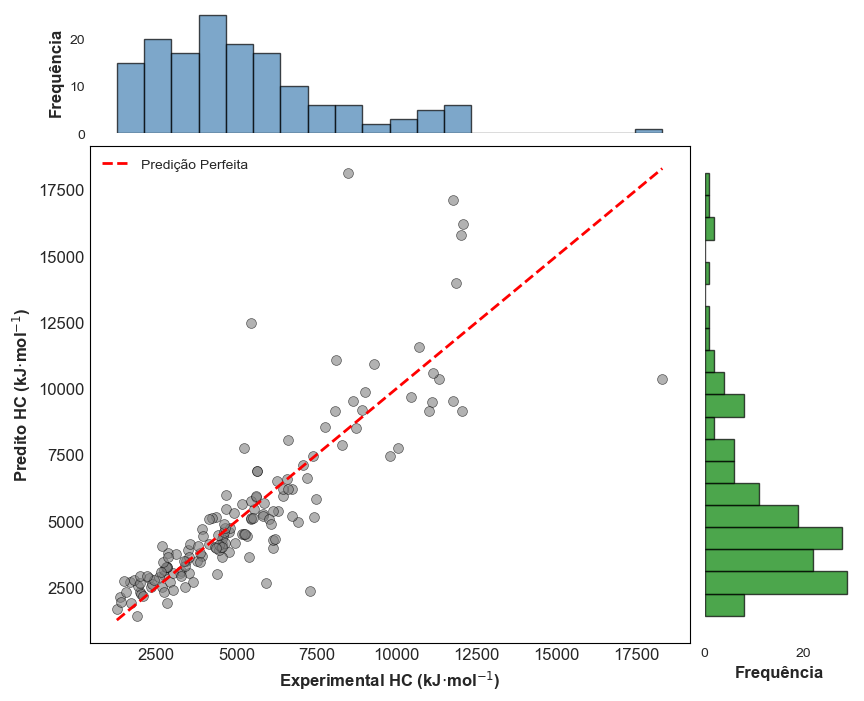

In [35]:
import os

# ============================================================
# Predito vs Experimental em LOOCV (Ridge | DFT+classes) - em HC
# ============================================================

# antigo: ax_main.scatter(y_true, y_pred_cv) onde y_* estavam em ln(HC)
# novo: usamos explicitamente HC (kJ/mol)
y_true_hc = y_true_ridge_classes_hc
y_pred_cv_hc = y_pred_cv_ridge_classes_hc

fig = plt.figure(figsize=(12, 10))
fig.patch.set_facecolor('white')

gs = fig.add_gridspec(3, 3, hspace=0.05, wspace=0.05, 
                      width_ratios=[1, 4, 1], height_ratios=[1, 4, 1])

ax_main = fig.add_subplot(gs[1, 1])
ax_main.scatter(y_true_hc, y_pred_cv_hc, alpha=0.6, s=50, c='gray', edgecolors='black', linewidth=0.5)
ax_main.set_facecolor('white')

min_val = min(y_true_hc.min(), y_pred_cv_hc.min())
max_val = max(y_true_hc.max(), y_pred_cv_hc.max())
ax_main.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predição Perfeita')

ax_main.set_xlabel('Experimental HC (kJ$\cdot$mol$^{-1}$)', fontsize=12, fontweight='bold')
ax_main.set_ylabel('Predito HC (kJ$\cdot$mol$^{-1}$)', fontsize=12, fontweight='bold')
ax_main.legend(loc='upper left')
ax_main.grid(True, alpha=0.3)
ax_main.tick_params(axis="x", labelsize=12)
ax_main.tick_params(axis="y", labelsize=12)


for spine in ax_main.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8)

# Top histogram
ax_top = fig.add_subplot(gs[0, 1], sharex=ax_main)
ax_top.set_facecolor('white')
ax_top.hist(y_true_hc, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax_top.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax_top.tick_params(labelbottom=False)
ax_top.grid(axis='y', alpha=0.3)
ax_top.tick_params(axis="y", labelsize=10)

# Right histogram
ax_right = fig.add_subplot(gs[1, 2], sharey=ax_main)
ax_right.set_facecolor('white')
ax_right.hist(y_pred_cv_hc, bins=20, orientation='horizontal', edgecolor='black', alpha=0.7, color='green')
ax_right.set_xlabel('Frequência', fontsize=12, fontweight='bold')
ax_right.tick_params(labelleft=False)
ax_right.grid(axis='x', alpha=0.3)
ax_right.tick_params(axis="y", labelsize=10)

name_arq = "Ridge_DFT-classes_LOOCV_Predito_vs_Experimental_em_HC"
caminho = r"C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures"

caminho_png = os.path.join(caminho, name_arq + ".png")
fig.savefig(caminho_png, dpi=600, bbox_inches='tight', facecolor='white')

caminho_svg = os.path.join(caminho, name_arq + ".svg")
fig.savefig(caminho_svg, format='svg', bbox_inches='tight', facecolor='white')

print(f"✅ Gráficos salvos em PNG e SVG na pasta:\n{caminho}")
plt.show()


✅ Gráficos salvos em PNG e SVG na pasta:
C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures


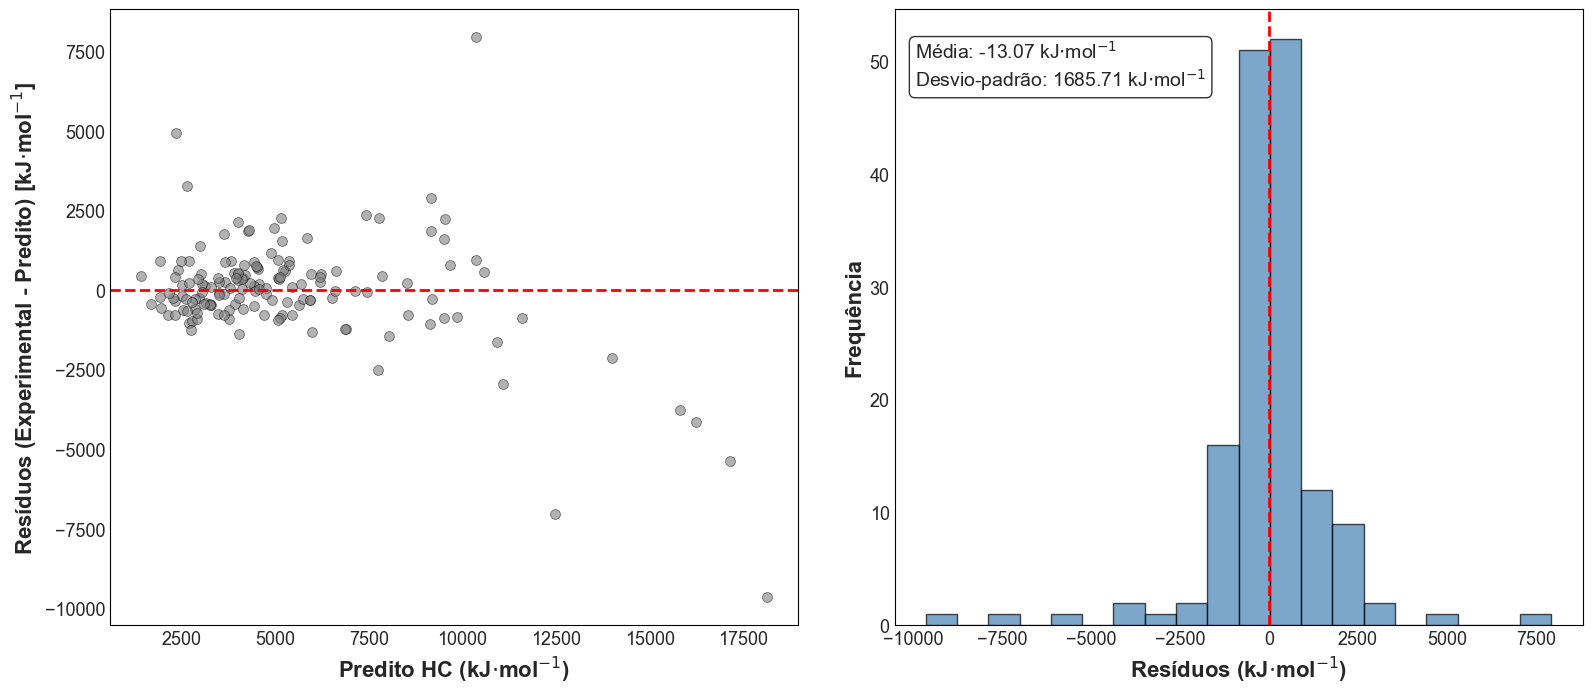

In [45]:
# ============================================================
# Diagnóstico de erro (Ridge | DFT + Classes) - em HC
# ============================================================

# antigo: residuals = y_true - y_pred_cv (em ln(HC))
# novo: resíduos em HC (kJ/mol)
residuals_hc = y_true_ridge_classes_hc - y_pred_cv_ridge_classes_hc

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(19, 8))

# Residuals vs Predicted
ax1.scatter(y_pred_cv_ridge_classes_hc, residuals_hc, alpha=0.6, s=50, c='gray', edgecolors='black', linewidth=0.5)
ax1.set_facecolor('white')
ax1.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax1.set_xlabel('Predito HC (kJ$\cdot$mol$^{-1}$)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Resíduos (Experimental - Predito) [kJ$\cdot$mol$^{-1}$]', fontsize=16, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis="x", labelsize=13)
ax1.tick_params(axis="y", labelsize=13)

# Histogram of residuals
ax2.hist(residuals_hc, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax2.set_facecolor('white')
ax2.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('Resíduos (kJ$\cdot$mol$^{-1}$)', fontsize=16, fontweight='bold')
ax2.set_ylabel('Frequência', fontsize=16, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

ax2.tick_params(axis="x", labelsize=13)
ax2.tick_params(axis="y", labelsize=13)


for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.8)

fig.subplots_adjust(wspace=0.14)

# Add statistics
mean_residual = residuals_hc.mean()
std_residual = residuals_hc.std()
stats_text = f"Média: {mean_residual:.2f} kJ$\cdot$mol$^{{-1}}$\nDesvio-padrão: {std_residual:.2f} kJ$\cdot$mol$^{{-1}}$"
ax2.text(0.03, 0.95, stats_text, transform=ax2.transAxes,
         fontsize=14, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


name_arq = "Ridge_DFTClasses_Diagnostico_Residuos_em_HC"
caminho = r"C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures"

caminho_png = os.path.join(caminho, name_arq + ".png")
fig.savefig(caminho_png, dpi=600, bbox_inches='tight', facecolor='white')

caminho_svg = os.path.join(caminho, name_arq + ".svg")
fig.savefig(caminho_svg, format='svg', bbox_inches='tight', facecolor='white')

print(f"✅ Gráficos salvos em PNG e SVG na pasta:\n{caminho}")

plt.show()


✅ Gráficos salvos em PNG e SVG na pasta:
C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures


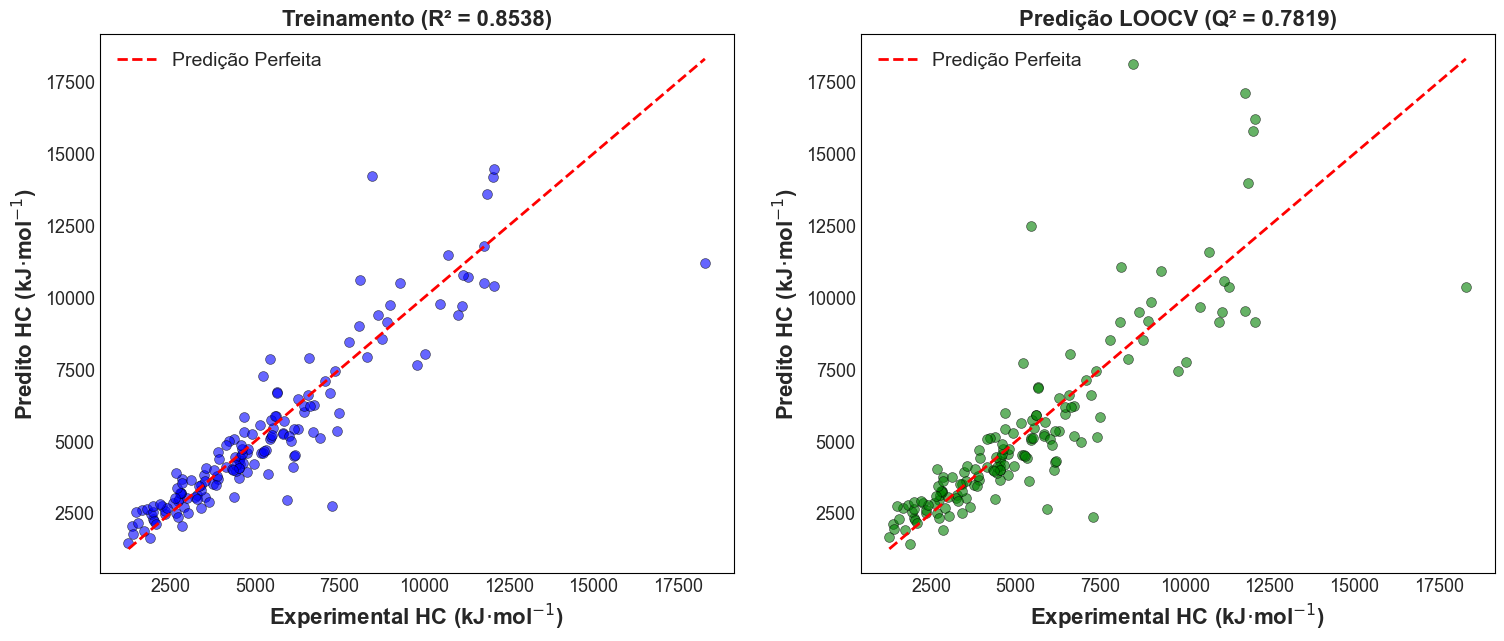

In [38]:
# ============================================================
# Predito vs Experimental – treino vs LOOCV (Ridge | DFT + Classes) - em HC
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Training predictions
ax1.scatter(y_true_ridge_classes_hc, y_pred_train_ridge_classes_hc, alpha=0.6, s=50, 
            edgecolors='black', linewidth=0.5, color='blue')
min_val = min(y_true_ridge_classes_hc.min(), y_pred_train_ridge_classes_hc.min())
max_val = max(y_true_ridge_classes_hc.max(), y_pred_train_ridge_classes_hc.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predição Perfeita')
ax1.set_facecolor('white')
ax1.set_xlabel('Experimental HC (kJ$\cdot$mol$^{-1}$)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Predito HC (kJ$\cdot$mol$^{-1}$)', fontsize=16, fontweight='bold')
ax1.set_title(f'Treinamento (R² = {ridge_classes_data["r2_train"]:.4f})', fontsize=16, fontweight='bold')
ax1.legend(fontsize=14)
ax1.grid(True, alpha=0.5)
ax1.tick_params(axis="x", labelsize=13)
ax1.tick_params(axis="y", labelsize=13)

# LOOCV predictions
ax2.scatter(y_true_ridge_classes_hc, y_pred_cv_ridge_classes_hc, alpha=0.6, s=50, 
            edgecolors='black', linewidth=0.5, color='green')
min_val = min(y_true_ridge_classes_hc.min(), y_pred_cv_ridge_classes_hc.min())
max_val = max(y_true_ridge_classes_hc.max(), y_pred_cv_ridge_classes_hc.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predição Perfeita')
ax2.set_facecolor('white')
ax2.set_xlabel('Experimental HC (kJ$\cdot$mol$^{-1}$)', fontsize=16, fontweight='bold')
ax2.set_ylabel('Predito HC (kJ$\cdot$mol$^{-1}$)', fontsize=16, fontweight='bold')
ax2.set_title(f'Predição LOOCV (Q² = {ridge_classes_data["q2_loocv"]:.4f})', fontsize=16, fontweight='bold')
ax2.legend(fontsize=14)
ax2.grid(True, alpha=0.5)
ax2.tick_params(axis="x", labelsize=13)
ax2.tick_params(axis="y", labelsize=13)

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.8)

name_arq = "Ridge_DFTClasses_Treino_vs_LOOCV_em_HC"
caminho = r"C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures"

caminho_png = os.path.join(caminho, name_arq + ".png")
fig.savefig(caminho_png, dpi=600, bbox_inches='tight', facecolor='white')

caminho_svg = os.path.join(caminho, name_arq + ".svg")
fig.savefig(caminho_svg, format='svg', bbox_inches='tight', facecolor='white')

print(f"✅ Gráficos salvos em PNG e SVG na pasta:\n{caminho}")

plt.show()
